# Chargement des bibliothèques

In [237]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch

from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error


#Paramètres et importations

Pipeline du projet :

Télécharger les prix historiques avec yfinance.

Calculer les rendements log.

Tester la stationnarité avec ADF/KPSS.

Étudier ACF/PACF pour guider le choix ARIMA.

Séparer train/test.

Ajuster un modèle ARIMA sur les rendements.

Diagnostiquer les résidus.

Ajuster un GARCH(1,1) ou GJR-GARCH(1,1) sur les résidus ou sur les rendements.

Produire des prévisions de rendement et de volatilité.

Faire un mini backtest et comparer à buy-and-hold.

# 1. Récupération des données et préparation des données

## 1.1. Téléchagement des données

In [3]:
SP500 = yf.download ('^GSPC', start = '2015-01-01', end = '2024-12-31')['Close']

[*********************100%***********************]  1 of 1 completed


## 1.2. Calcul des rendements logarithmiques

In [4]:
returns = np.log (SP500/SP500.shift()) *100
returns = returns.dropna()
print (returns.head(10))

Ticker         ^GSPC
Date                
2015-01-05 -1.844721
2015-01-06 -0.893325
2015-01-07  1.156274
2015-01-08  1.773017
2015-01-09 -0.843932
2015-01-12 -0.812662
2015-01-13 -0.258189
2015-01-14 -0.583003
2015-01-15 -0.929090
2015-01-16  1.333489


## 1.3. Visualisation de la série et des rendements

Text(0, 0.5, 'Rendement (%)')

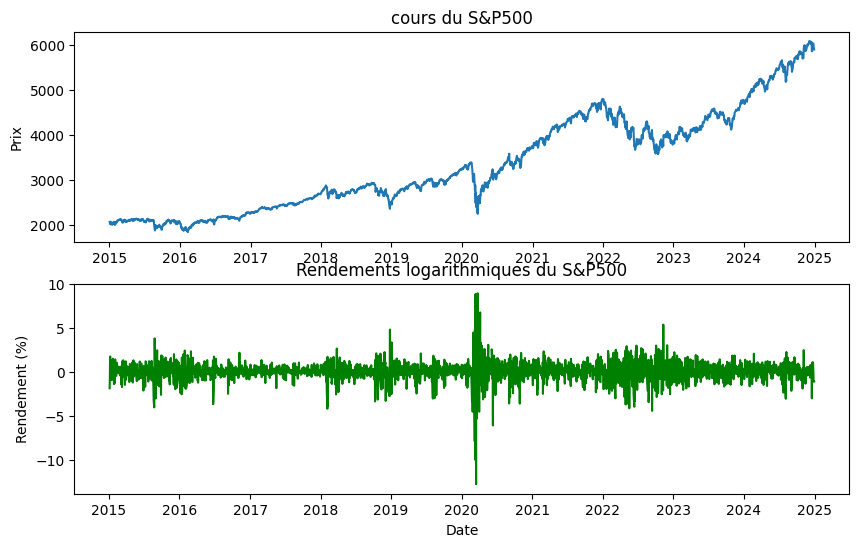

In [5]:
fig, ax = plt.subplots (2,1, figsize = (10,6))
ax[0].plot (SP500)
ax[0].set_title ('cours du S&P500')
ax[0].set_ylabel ('Prix')

ax[1].plot (returns, color = 'green')
ax[1].set_title ('Rendements logarithmiques du S&P500')
ax[1].set_xlabel ('Date')
ax[1].set_ylabel ('Rendement (%)')

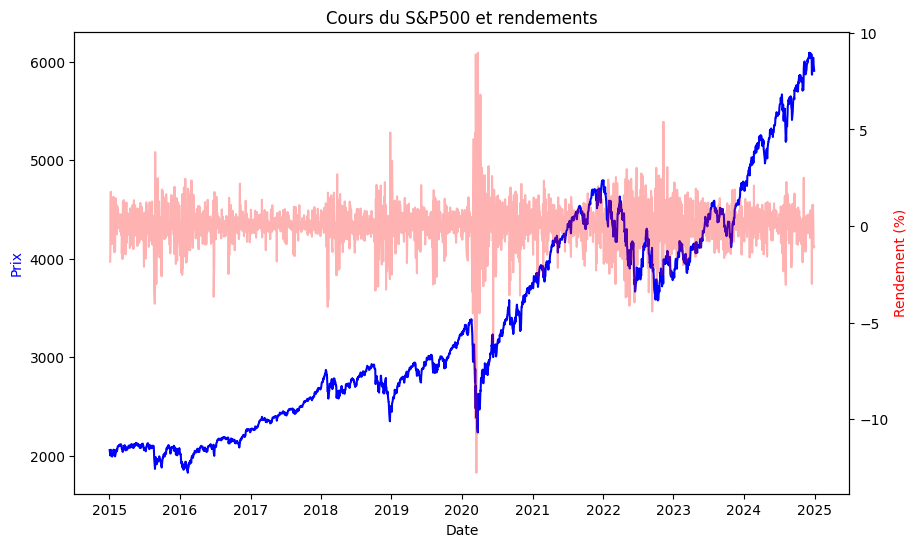

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(SP500, color="blue", label="Cours du S&P500")
ax1.set_ylabel("Prix", color="blue")

ax2 = ax1.twinx()
ax2.plot(returns, color="red", alpha=0.3, label = 'Rendements')
ax2.set_ylabel("Rendement (%)", color="red")

ax1.set_title("Cours du S&P500 et rendements")
ax1.set_xlabel("Date")
plt.show()

# 2. Séparation des données train/test

In [7]:
train_data = returns [:'2021']
test_data = returns ['2022' :]

In [8]:
train_data.tail(10)

Ticker,^GSPC
Date,
2021-12-17,-1.034096
2021-12-20,-1.145340
2021-12-21,1.762176
2021-12-22,1.012873
2021-12-23,0.620441
2021-12-27,1.374405
2021-12-28,-0.101067
2021-12-29,0.140091
2021-12-30,-0.299423


In [9]:
test_data.head (10)

Ticker,^GSPC
Date,
2022-01-03,0.635382
2022-01-04,-0.062982
2022-01-05,-1.958326
2022-01-06,-0.096423
2022-01-07,-0.405844
2022-01-10,-0.144207
2022-01-11,0.911829
2022-01-12,0.281379
2022-01-13,-1.434603


# 3. Analyse exploratoire (sur les données train)

## 3.1. Test ADF

In [10]:
p_value = adfuller (train_data) [1]
print (p_value)

1.3686559526128454e-24


p-values < 5%, alors la série est stationnaire

## 3.2. Visualisation ACF/PACF

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

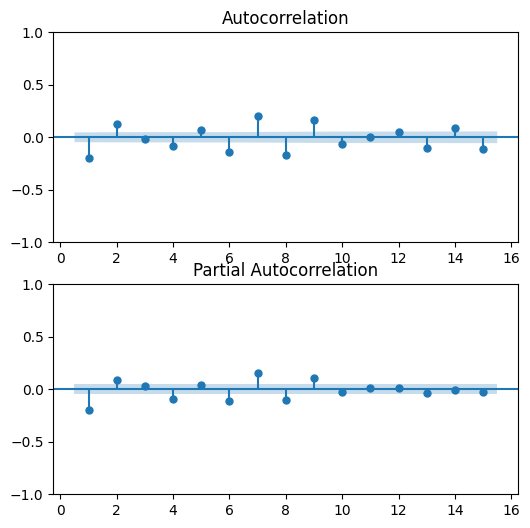

In [12]:
fig, (ax1, ax2) = plt.subplots (2,1, figsize = (6,6))

plot_acf (train_data, lags = 15, zero = False, ax = ax1)
plot_pacf (train_data, lags = 15, zero = False, ax= ax2)

plt.show()

**Interprétation ACF - PACF** :

Nous n'avons de queue longue ni dans ACF ni dans PACF, et seulement 1-2 lags vraiment visibles dans chaque schéma

Nous pouvons donc suggérer un modèle ARMA avec p et q de faibles ordres ou un modèle AR de faible ordre

Les graphes ACF et PACF ne montrent pas de gros lags significatifs, la série est donc déjà stationnaire (d=0). 


# 4. Sélection et estimation du modèle ARIMA

## 4.1. Recherche du meilleur modèle ARIMA

In [13]:
arma_params = []

for p in range (4) : 
    for q in range (4) :
        arma_model = ARIMA (train_data, order =(p, 0, q))
        arma_results = arma_model.fit()
        arma_params.append((p,q, arma_results.aic, arma_results.bic))
        
arma_selection = pd.DataFrame (arma_params, columns= ['p', 'q', 'AIC', 'BIC'])
print (arma_selection.sort_values ('AIC')) #classement des modèles selon le critère AIC


c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

    p  q          AIC          BIC
14  3  2  5275.485207  5313.804641
13  3  1  5312.227950  5345.073179
11  2  3  5371.224546  5409.543980
7   1  3  5371.658575  5404.503804
3   0  3  5372.760711  5400.131735
15  3  3  5372.973710  5416.767348
10  2  2  5373.337755  5406.182984
2   0  2  5373.775097  5395.671916
6   1  2  5374.183863  5401.554887
8   2  0  5376.382054  5398.278873
12  3  0  5376.823387  5404.194411
9   2  1  5377.870183  5405.241207
5   1  1  5382.258903  5404.155722
4   1  0  5389.107499  5405.530113
1   0  1  5401.631177  5418.053791
0   0  0  5457.183868  5468.132277


In [14]:
arma_selection.sort_values ('BIC') #classement des modèles en fonctions des citères BIC

,p,q,AIC,BIC
14,3,2,5275.485207,5313.804641
13,3,1,5312.227950,5345.073179
2,0,2,5373.775097,5395.671916
8,2,0,5376.382054,5398.278873
3,0,3,5372.760711,5400.131735
6,1,2,5374.183863,5401.554887
5,1,1,5382.258903,5404.155722
12,3,0,5376.823387,5404.194411
7,1,3,5371.658575,5404.503804
9,2,1,5377.870183,5405.241207


Les modèles ARIMA (3,0,2) présentent les meilleurs indicateurs AIC et BIC

## 4.2. Diagnostic de notre modèle ARIMA

In [15]:
arma_model = ARIMA (train_data, order=(3,0,2))
arma_results = arma_model.fit()
arma_residuals= arma_results.resid
#Calcul de la MAE
print (np.mean(np.abs(arma_residuals)))

c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


0.6947500331722714


La Mean Absolute Error est très proche de 0, donc notre modèle est fiable

<Figure size 1000x600 with 0 Axes>

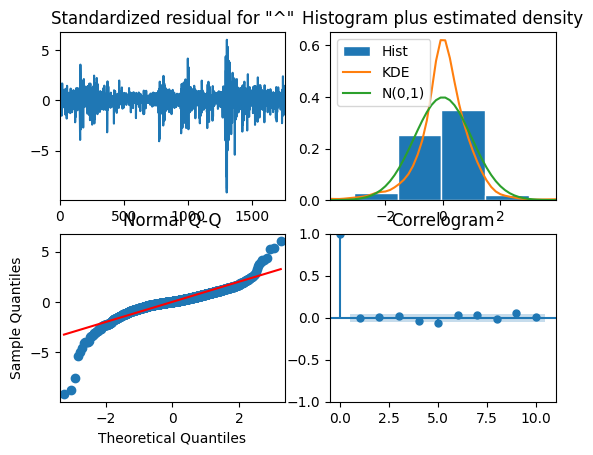

In [16]:
plt.figure (figsize = (10,6))
arma_results.plot_diagnostics()
plt.show()

In [17]:
print (arma_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                 1762
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -2630.743
Date:                Mon, 28 Sep 2026   AIC                           5275.485
Time:                        14:31:04   BIC                           5313.805
Sample:                             0   HQIC                          5289.646
                               - 1762                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0476      0.027      1.795      0.073      -0.004       0.100
ar.L1         -1.7149      0.030    -58.052      0.000      -1.773      -1.657
ar.L2         -0.8541      0.042    -20.575      0.0

Le coefficient ar.L1 = -1.71 est significatif, et ar.L2 = -0.8541 l’est aussi, ce qui veut dire que les deux derniers retours passés apportent de l’information statistiquement exploitable sur la valeur actuelle.

Le coefficient ar.L3 = 0.0115 n'est pas significatif (p-value = 0.494 > 5%), ce qui interroge sur l'utilisation d'un AR=3 dans notre modèle. 

**Diagnostics des résidus**

Le test de Ljung-Box affiche une p-value de 0.99, ce qui est un indicateur positif : il ne reste probablement pas d’autocorrélation linéaire dans les résidus à ce lag, ils se comportent comme un bruit blanc.
Autrement dit, le modèle a bien capturé la dépendance temporelle principale de la série

En revanche, le test de Jarque-Bera est énorme (12586.72) et sa p-value est 0.00, donc les résidus ne suivent pas une loi normale.

La skewness est -1.22 et la kurtosis 15.86, ce qui indique une distribution très asymétrique à gauche et surtout à queues épaisses, un comportement classique des rendements financiers.

## 4.3. Test ARCH-LM sur les résidus

In [240]:
#Exécution du test de ARCH-LM sur les résidus du modèle ARMA afin de détecter la présence d'hétéroscédasticité conditionnelle

lm_stat, lm_p_value, f_stat, fpval = het_arch(arma_residuals, nlags=5)

print(f"Statistique du test ARCH-LM : {lm_stat:.4f}")
print(f"Valeur p du test ARCH-LM : {lm_p_value:.4f}")

Statistique du test ARCH-LM : 561.4946
Valeur p du test ARCH-LM : 0.0000


p-value < 5%, on peut donc rejetter l'hypothèse nulle  H0 et conclure qu'il existe un effet arch (d'hétéroscédasticité) entre nos résidus, la volatilité passée influence la volatilité actuelle.

Nous devrons donc passer à un modèle GARCH pour modéliser la volatilité

# 5. Sélection et estimation du modèle GARCH

## 5.1. Modèle GARCH Simple

In [19]:
garch_model = arch_model (arma_residuals, p= 1, q=1, mean = 'zero', vol = 'GARCH', dist = 't')
garch_result = garch_model.fit (disp = 'off')

In [251]:
print(garch_result.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -2111.35
Distribution:      Standardized Student's t   AIC:                           4230.70
Method:                  Maximum Likelihood   BIC:                           4252.59
                                              No. Observations:                 1762
Date:                      Mon, Sep 28 2026   Df Residuals:                     1762
Time:                              14:31:16   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

Les paramètres alpha, beta et omega sont tous significatifs (p-value < 5%)

La somme des paramètres alpha et beta est très proche de 1, ce qui signifie que les chocs de volatilité mettent du temps à s'estomper, la volatilité au jour t est fortement dépendante à celle du jour précédent (persistance élevée)

## 5.2. Modèle GJR GARCH

In [256]:
gjr_model = arch_model (arma_residuals, p= 1, q=1, o = 1, mean = 'zero', vol = 'GARCH', dist = 't')
gjr_result = gjr_model.fit()
print (gjr_result.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 28612.64668955407
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2441.8066029379697
Iteration:      3,   Func. Count:     23,   Neg. LLF: 2095.6809705816045
Iteration:      4,   Func. Count:     30,   Neg. LLF: 2089.7619469405736
Iteration:      5,   Func. Count:     37,   Neg. LLF: 2822.9179107831956
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2084.4670457367647
Iteration:      7,   Func. Count:     52,   Neg. LLF: 2087.2312661101096
Iteration:      8,   Func. Count:     59,   Neg. LLF: 2083.4909067015474
Iteration:      9,   Func. Count:     66,   Neg. LLF: 2083.478860557966
Iteration:     10,   Func. Count:     72,   Neg. LLF: 2083.4784516787686
Iteration:     11,   Func. Count:     78,   Neg. LLF: 2083.4784431476455
Iteration:     12,   Func. Count:     84,   Neg. LLF: 2083.47844233498
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2083.47844233498
            Iteration

In [260]:
print (gjr_result.summary())
print()
print (gjr_result.params ['alpha[1]' ] + 0.5 * gjr_result.params ['gamma[1]'] + gjr_result.params ['beta[1]'])

                        Zero Mean - GJR-GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2083.48
Distribution:      Standardized Student's t   AIC:                           4176.96
Method:                  Maximum Likelihood   BIC:                           4204.33
                                              No. Observations:                 1762
Date:                      Tue, Sep 29 2026   Df Residuals:                     1762
Time:                              04:35:25   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

Le paramètre gamma est significatif (p-value <5%) avec une std proche de zéro. Son coefficient est positif et égal à 0,2840 suggérant une asymétrie, les mauvaises nouvelles amplifient plus la volatilité que les bonnes nouvelles.

La somme des paramètres alpha et beta est très proche de 1, ce qui signifie que les chocs de volatilité mettent du temps à s'estomper, la volatilité au jour t est fortement dépendante à celle du jour précédent (persistance élevée)

La somme des paramètres alpha, 0.5 omega et beta est égale à 0.98 et donc inférieur à 1, ce qui signifie que le modèle est stationnaire mais avec une persistance élevée

## 5.3. Choix du modèle GARCH

In [22]:
indicateurs = pd.DataFrame (columns = ('GARCH', 'GJR-GARCH'), index = ('Likelihood', 'AIC', 'BIC'))
indicateurs ['GARCH'] = [garch_result.loglikelihood, garch_result.aic, garch_result.bic]
indicateurs ['GJR-GARCH'] = [gjr_result.loglikelihood, gjr_result.aic, gjr_result.bic]
print (indicateurs)

                  GARCH    GJR-GARCH
Likelihood -2111.348787 -2083.478442
AIC         4230.697573  4176.956885
BIC         4252.594392  4204.327909


Le modèle GJR-GARCH présente de meilleurs indicateurs que le modèle GARCH, nous l'utiliserons donc pour nos forecast

# 6. Prévisions

## 6.1. Prévisions des rendements futurs

In [23]:
#Utilisation d'une fenêtre roulante

n_train = len (train_data)
n_test = len (test_data)
predicted_returns = []

for i in range (n_test) : 
    window_data = returns.iloc [:n_train + i]  #la fenêtre glissante comporte toute les données test et s'incrémente à chaque fois du rendement suivant
    p_model = ARIMA (window_data, order = (3,0,2))  #pour rappel le meilleur model ARIMA est d'ordre (3,0,2)
    p_result = p_model.fit()
    predicted_ret = p_result.forecast (steps = 1)
    predicted_returns.append(predicted_ret.iloc [0])

arima_returns = pd.Series (predicted_returns, index = test_data.index)



c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\merry\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

In [37]:
arima_returns

Date
2022-01-03    0.001773
2022-01-04   -0.067699
2022-01-05    0.191896
2022-01-06    0.173065
2022-01-07    0.045163
                ...   
2024-12-23   -0.107856
2024-12-24    0.184944
2024-12-26   -0.217065
2024-12-27    0.278835
2024-12-30   -0.023827
Length: 752, dtype: float64

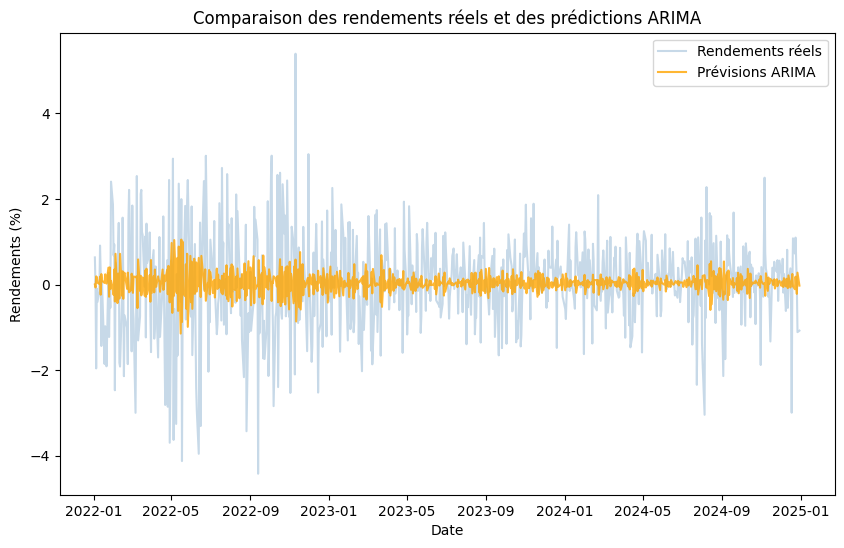

In [101]:
#Visualisation des rendements réels et des rendements prédictifs
plt.figure (figsize = (10,6))
plt.plot (test_data, color = 'steelblue', alpha = 0.3, label = 'Rendements réels')
plt.plot (arima_returns, color = 'orange', alpha = 0.8, label = 'Prévisions ARIMA')
plt.title ('Comparaison des rendements réels et des prédictions ARIMA')
plt.xlabel ('Date')
plt.ylabel ('Rendements (%)')
plt.legend()
plt.show()

**Interprétation :**

Les prévisions ARIMA (en orange) oscillent dans une bande beaucoup plus étroite que les rendements réels (en bleu), et restent globalement proches de zéro, y compris lors des épisodes de forte volatilité (mi-2022, fin 2022 observés dans le graphique de volatilité plus bas). 

Ce comportement est cohérent avec ce qu'on observe en section 7.1 : le modèle ne bat pas une prévision constante sur les rendements out-of-sample, il ne fait donc qu'un lissage limité autour d'une valeur proche de la moyenne, sans anticiper l'amplitude ni le sens des mouvements réels.

Cela confirme que l'ARIMA, ici, capture surtout une faible dépendance linéaire de court terme dans les rendements, plutôt qu'un signal prédictif exploitable, ce qui est attendu sur des rendements financiers proches d'un bruit blanc en moyenne.

## 6.2. Création d'une nouvelle série de résidus

Nous avons déjà une série de résidus (arma_residuals) correspondant aux résidus in-sample, les erreurs d'ajustement/estimation sur nos données train_data.

Avec les estimations de rendements, nous pouvons déduire une nouvelle série de résidus correspondant aux erreurs d'ajustement/estimation sur les données test_data (prévisions à un pas). 

Nous allons ensuite créer une série de résidus qui a la même taille que la série totale de rendements, elle sera la somme des deus séries de résidus précédentes. Cette série est nécessaire pour l'estimation du modèle GARCH sur l'ensemble des données.


In [139]:
#Construction des résidus in-sample
test_residuals = test_data.iloc [:,0] - arima_returns
#print (test_residuals)

#Concatenation des résidus de l'échantillon d'apprentissage et de l'échantillon de test
all_residuals = pd.concat ([arma_residuals, test_residuals])
print (all_residuals)

print (len(all_residuals) == len(returns)) #nous vérifions que la série de résidus a la même taille que la série de rendements
print (all_residuals.index.equals (returns.index)) #nous vérifions que les index de la série de résidus et de la série de rendements sont identiques

Date
2015-01-05   -1.892355
2015-01-06   -1.312990
2015-01-07    1.102427
2015-01-08    2.028210
2015-01-09   -0.828550
                ...   
2024-12-23    0.833941
2024-12-24    0.913279
2024-12-26    0.176491
2024-12-27   -1.390566
2024-12-30   -1.052140
Length: 2514, dtype: float64
True
True


## 6.3. Configuration du nouveau modèle GARCH

In [140]:
gjr_full = arch_model (all_residuals, p= 1, q=1, o = 1, mean = 'zero', vol = 'GARCH', dist = 't')
gjr_full_result = gjr_full.fit()
print (gjr_full_result.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 13722.372221900758
Iteration:      2,   Func. Count:     17,   Neg. LLF: 4088.572842959265
Iteration:      3,   Func. Count:     25,   Neg. LLF: 3178.356822353653
Iteration:      4,   Func. Count:     32,   Neg. LLF: 3188.6912901183614
Iteration:      5,   Func. Count:     39,   Neg. LLF: 3171.4658310044274
Iteration:      6,   Func. Count:     46,   Neg. LLF: 3226.033627877107
Iteration:      7,   Func. Count:     54,   Neg. LLF: 3170.994394776802
Iteration:      8,   Func. Count:     61,   Neg. LLF: 3168.571808597922
Iteration:      9,   Func. Count:     67,   Neg. LLF: 3168.5665288380233
Iteration:     10,   Func. Count:     73,   Neg. LLF: 3168.566509549511
Iteration:     11,   Func. Count:     78,   Neg. LLF: 3168.566509549522
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3168.566509549511
            Iterations: 11
            Function evaluations: 78
            Gradient evaluations

## 6.4. Prévision de la volatilité sur la période test

In [150]:
#Utilisation d'une fenêtre roulante pour les prévisions de la volatilité
predicted_variance = []

n_train = len (train_data)
n_test = len (test_data)

for i in range (n_test) : 
    gjr_window = gjr_full.fit (first_obs= 0, last_obs= n_train + i, disp='off', show_warning=False)
    variance_forecast = gjr_window.forecast (align='origin', horizon = 1, reindex = False)
    var_1step = variance_forecast.variance.iloc[0,0]
    predicted_variance.append (var_1step)

#gjr_variance = pd.Series (predicted_variance, index = test_data.index [:3])
#gjr_vol = np.sqrt (gjr_variance)

gjr_forecast = pd.DataFrame (index = test_data.index [:n_test])
gjr_forecast ['Variance'] = predicted_variance
gjr_forecast ['Volatilité'] = np.sqrt (gjr_forecast ['Variance'])

print (gjr_forecast)

            Variance  Volatilité
Date                            
2022-01-03  0.580600    0.761971
2022-01-04  0.510070    0.714192
2022-01-05  0.438401    0.662119
2022-01-06  1.838757    1.356008
2022-01-07  1.535953    1.239336
...              ...         ...
2024-12-23  2.059441    1.435075
2024-12-24  1.783152    1.335347
2024-12-26  1.552885    1.246148
2024-12-27  1.341886    1.158398
2024-12-30  1.649526    1.284339

[752 rows x 2 columns]


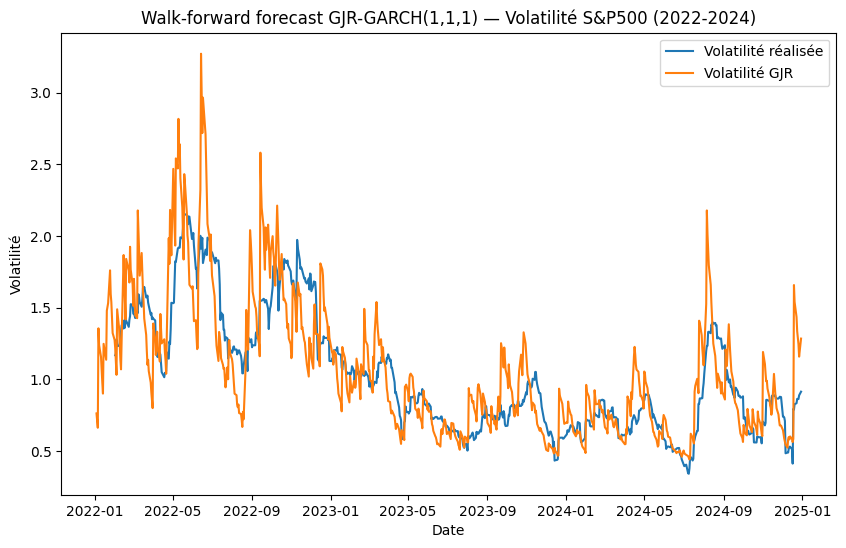

In [152]:
#Visualisation volatilité réalisée et volatilité gjr

#Calcul de la volatilité réalisée
vol_real = test_data.rolling(window = 21).std()

plt.figure (figsize = (10,6))
plt.plot (vol_real, label = 'Volatilité réalisée')
plt.plot (gjr_forecast ['Volatilité'], label = 'Volatilité GJR')
plt.title ('Walk-forward forecast GJR-GARCH(1,1,1) — Volatilité S&P500 (2022-2024)')
plt.xlabel ('Date')
plt.ylabel ('Volatilité')
plt.legend()
plt.show()

# 7. Evaluation des performances du modèle

## 7.1. Modèle ARIMA

In [ ]:
#Conversion des données test en 1-D array
y_reel = np.array (test_data).ravel()
y_pred = np.array (arima_returns).ravel()
pred_naive = test_data.mean () #nous utilisons la moyenne des rendements de l'échantillon out-of sample comme prédiction naïve


mae_ret = mean_absolute_error (y_reel, y_pred)
rmse_ret = np.sqrt (mean_squared_error (y_reel, y_pred))

mae_ret_naive = mean_absolute_error (y_reel, np.full_like(y_reel, pred_naive))
rmse_ret_naive = np.sqrt (mean_squared_error (y_reel, np.full_like(y_reel, pred_naive)))



print ('Métriques de prédiction ARIMA')
print (f'MAE : {mae_ret: .4f} %')
print (f'RMSE : {rmse_ret: .4f} %')
print()
print ('Métriques de prédiction naïve')
print (f'MAE : {mae_ret_naive: .4f} %')
print (f'RMSE : {rmse_ret_naive: .4f} %')

Métriques de prédiction ARIMA
MAE :  0.8361 %
RMSE :  1.1207 %

Métriques de prédiction naïve
MAE :  0.8123 %
RMSE :  1.1026 %


Notre modèle ARIMA ressort des indicateurs moins bons que ceux de notre benchmark.

Ce résultat est assez logique, l'ARIMA ne bat pas une prévision constante sur les rendements, ce qui est cohérent avec l'hypothèse de marché efficient : les rendements financiers sont proches d'un bruit blanc en moyenne, donc difficiles à prévoir avec un modèle linéaire simple.

A noter : nous aurions également pu utiliser la valeur du rendement de la période précédente comme prédiction naïve ou encore une moyenne à zéro (moyenne sur le long terme). Nous avons testé rapidement, la finalié est la même, le modèle ARIMA ne produit pas de meilleurs rendements

## 7.2. Modèle GARCH

In [227]:
mask          = ~vol_real.squeeze().isna() #nous avons transformé vol_real en pandas.Series afin de pouvoir appliquer le masque aux autres pandas.Series
vol_true      = vol_real [mask].values
vol_pred_mask = gjr_forecast ['Volatilité'][mask].values

mae_vol  = mean_absolute_error(vol_true, vol_pred_mask)
rmse_vol = np.sqrt(mean_squared_error(vol_true, vol_pred_mask))

print("\n=== Métriques GJR-GARCH (volatilité) ===")
print(f"  MAE  : {mae_vol:.4f} %")
print(f"  RMSE : {rmse_vol:.4f} %")


=== Métriques GJR-GARCH (volatilité) ===
  MAE  : 0.2030 %
  RMSE : 0.2799 %


## 7.3. Comparaison

Nous allons comparer ces métriques à la persistance. La volatilité a une forte autocorrélation, ce qui signifie que la volatilité du jour t a tendance à être celle du jout t+1 (principe de GARCH).

Nous allons donc décaler la volatilité déterminée précédemment d'un jour, recalculer les métriques et comparer pour savoir si notre modèle GJR performe bien.

In [ ]:
vol_naive =  vol_real.squeeze().shift(1)

mask = ~vol_naive.isna()
vol_true = vol_real [mask].values
vol_naive_mask = vol_naive [mask].values

mae_vol_naive  = mean_absolute_error(vol_true, vol_naive_mask)
rmse_vol_naive = np.sqrt(mean_squared_error(vol_true, vol_naive_mask))

print("\n=== Métriques persistance de la volatilité ===")
print(f"  MAE  : {mae_vol_naive:.4f} %")
print(f"  RMSE : {rmse_vol_naive:.4f} %")


=== Métriques persistance de la volatilité ===
  MAE  : 0.0349 %
  RMSE : 0.0589 %


En comparant les métriques, nous voyons que le benchmark (la persistance) produit des métriques largement supérieures à GJR, ce qui suppose un biais. 
Vol_real est un écart-type glissant sur 21 jours, les données sont donc fortement autocorrelées, deux jours consécutifs peuvent facilement se retrouver avec des valeurs presques identiques donnant un meilleur score à la persistance. Nous allons tenter une approche pour corriger ce biais

## 7.4. Métriques plus robustes pour modèle GARCH

Cette fois nous remplacerons l'écart-type glissant sur 21 jours par le rendement carré du jour, qui est un proxy bruité de la variance (pas de la volatilité)

In [ ]:
vol_proxy = test_data.iloc[:, 0] ** 2
vol_proxy_naive = vol_proxy.shift(1) #nouvelle persistance

mask = ~vol_proxy_naive.isna()
vol_proxy_true = vol_proxy[mask]
vol_proxy_naive_mask = vol_proxy_naive[mask]
vol_predict_mask = gjr_forecast['Variance'][mask] #attention, nous travaillons cette fois avec les variances

mae_vol_proxy  = mean_absolute_error(vol_proxy_true, vol_predict_mask)
rmse_vol_proxy = np.sqrt(mean_squared_error(vol_proxy_true, vol_predict_mask))

mae_vol_proxy_naive  = mean_absolute_error(vol_proxy_true, vol_proxy_naive_mask)
rmse_vol_proxy_naive = np.sqrt(mean_squared_error(vol_proxy_true, vol_proxy_naive_mask))

print("\n=== Métriques GJR-GARCH ===")
print(f"  MAE  : {mae_vol_proxy:.4f} %")
print(f"  RMSE : {rmse_vol_proxy:.4f} %")

print("\n=== Métriques persistance de la volatilité proxy ===")
print(f"  MAE  : {mae_vol_proxy_naive:.4f} %")
print(f"  RMSE : {rmse_vol_proxy_naive:.4f} %")



=== Métriques GJR-GARCH (volatilité proxy) ===
  MAE  : 1.3087 %
  RMSE : 2.3583 %

=== Métriques persistance de la volatilité proxy ===
  MAE  : 1.6579 %
  RMSE : 3.1710 %


Cette fois le GJR montre de meilleurs résultats que la persistance : MAE 1.31% contre 1.66% et RMSE à 2.36% contre 3.17%.
C'est un résultat solide qui vient valider notre modèle GJR.

ça confirme également notre intuition précédente, les mauvais résultats du GJR contre la persistance sur l'écart-type glissant venait bien du copié-collé relatif des valeurs entre deux jours consécutifs, ce qui avantageait la persistance.